# Selecting a region of interest 

Region-of-interest selection is not mandatory, but it can help focus on a specific region or reduce the size of the sample and therefore speed up the analysis by excluding background regions.
These regions may still contain small amounts of transcripts, and by removing them, we can skip the processing altogether.

There are 2 ways of selecting the region of interest:
- cropping to a rectangular subsection of the sample
- masking using a binary mask to select an arbitrary area

We will demonstrate both using a Stereo-seq sample, but this applies equally to all technologies.

First, we want to load the sample and get a quick overview of what it looks like.
For more information on data loading (especially for different technologies), please refer to the {doc}`data loading tutorial <io>`.

We can load the data and visualize the total mRNA.

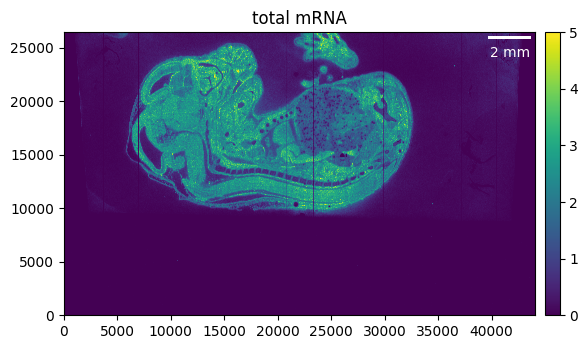

In [1]:
from pathlib import Path

from sainsc.io import read_StereoSeq

# Load the Stereo-seq dataset.
gem_file = Path("path/to/stereoseq_data") / "E16.5_E1S3_GEM_bin1.tsv.gz"
embryo = read_StereoSeq(gem_file)

# Calculate and visualize the total mRNA.
# Here we set the maximum value as well to better highlight the background noise.
embryo.calculate_total_mRNA()
_ = embryo.plot_genecount(im_kwargs={"vmax": 5})

## Cropping the sample

We can see that the region of interest in our case is much smaller than the total area of our sample.
Cropping helps to focus only on the relevant parts of our tissue and, on top of that, will reduce memory usage and processing time.

As a first step, we can crop away the parts of the tissue that we don't need.
Make sure to recalculate the total mRNA, as otherwise the previously calculated counts will be shown.

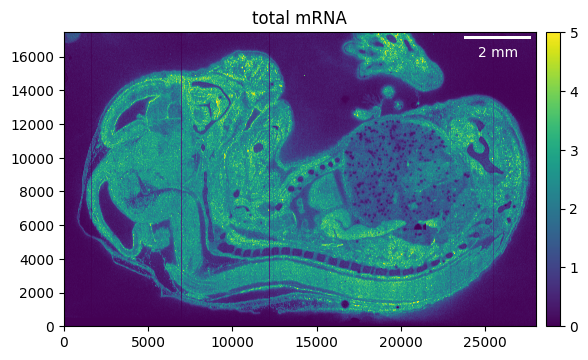

In [2]:
# The cropping area is defined as (x_min, x_max), (y_min, y_max).
# None can be used to crop to the Minimum or maximum value, respectively.
embryo.counts.crop((5_000, 33_000), (9_000, None))

embryo.calculate_total_mRNA()
_ = embryo.plot_genecount(im_kwargs={"vmax": 5})

## Arbitrary masking

If we want to go even further, we can "mask" the exact region of interest.
For example, we can export the count array and use it to manually draw a selection mask.

In [3]:
import numpy as np
from PIL import Image

# export total mRNA as png
u8 = np.uint8
Image.fromarray(
    np.clip(embryo.total_mRNA, np.iinfo(u8).min, np.iinfo(u8).max).astype(u8)
).save("counts.png")

This is what our region of interest (ROI) looks like after manually drawing the outline ...

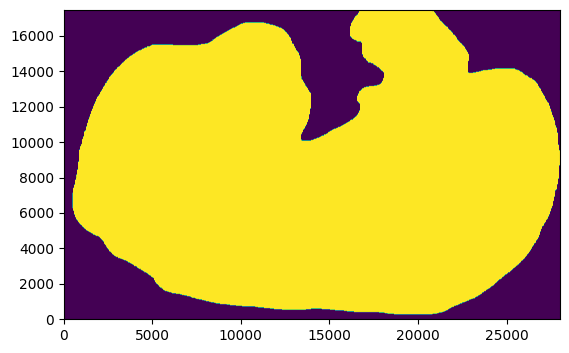

In [4]:
import matplotlib.pyplot as plt

# This is just needed to load the example data
from sainsc.datasets import fetch_embryo_mask

# Avoid the DecompressionBombError because the image is quite large.
Image.MAX_IMAGE_PIXELS = None

mask_file = fetch_embryo_mask()  # here you would add your own selection mask
embryo_mask = np.array(Image.open(mask_file), dtype=bool)

# Pay attention to the origin.
# Sainsc typically plots the origin in the lower left, while for images it is usually the upper left.
# Also, the x-y coordinates are usually transposed; that's why we transpose the matrix here, so it has the same orientation as the sample.
_ = plt.imshow(embryo_mask.T, origin="lower")

Using it to filter the counts is easy, just make sure that the shape of the mask and the sample are the same.

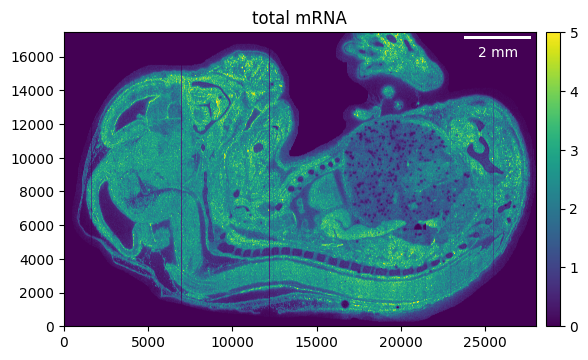

In [5]:
embryo.counts.filter_mask(embryo_mask)

embryo.calculate_total_mRNA()

_ = embryo.plot_genecount(im_kwargs={"vmax": 5})

As a final tip: We can also filter the genes that have no counts left after cropping and masking.

In [6]:
embryo.counts.filter_genes_by_count(1)